In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("Data/Data_MLB_2025_StatcastPostseason_PitchByPitch_20251102a.csv")

In [3]:
print(df.shape)
df.head()

(14096, 95)


,game_year,game_date,player_name,pitcher,batter,balls,strikes,inning,inning_topbot,at_bat_number,...,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
0,2025,2025-09-30,"Ashcraft, Graham",668933,605141,0,0,8,Bot,73,...,10,10,5,Standard,Standard,42.0,0.0,0.041,NaN,NaN
1,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,0,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,-0.050,NaN,NaN
2,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,1,8,Bot,73,...,10,10,5,Standard,Standard,23.0,0.0,-0.061,65.0,6.0
3,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,39.0,0.0,0.000,53.1,7.2
4,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,0.043,NaN,NaN


In [11]:
pitch_outcome_num = []
for i in range(df.shape[0]):
    if df.loc[i, 'description'] in ['called_strike', 'foul', 'swinging_strike', 'foul_tip']:
        pitch_outcome_num.append(1)
    elif df.loc[i, 'description'] == 'ball':
        pitch_outcome_num.append(0)
    else:
        pitch_outcome_num.append(2)

df['outcome'] = pitch_outcome_num

## Looking at distribution of balls, strikes, and hits
See if there is need to balance weights

Text(0.5, 1.0, 'Distribution of balls, strikes, and balls put in play in data set')

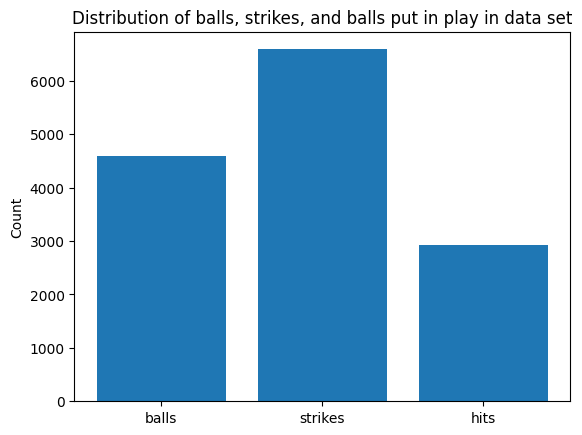

In [17]:
counts = [len(df[df['outcome'] == 0]), len(df[df['outcome'] == 1]), len(df[df['outcome'] == 2])]
names = ['balls', 'strikes', 'hits']

plt.bar(names, counts)
plt.ylabel("Count")
plt.title("Distribution of balls, strikes, and balls put in play in data set")

# Probaility at each count

[0, 0] Count: probability of strike = 0.5970341715022566 probability of ball = 0.40296582849774343
[1, 0] Count: probability of strike = 0.6267154620311071 probability of ball = 0.37328453796889294
[2, 0] Count: probability of strike = 0.6412429378531074 probability of ball = 0.3587570621468926
[3, 0] Count: probability of strike = 0.6390977443609023 probability of ball = 0.3609022556390977
[0, 1] Count: probability of strike = 0.5275103163686382 probability of ball = 0.4724896836313618
[1, 1] Count: probability of strike = 0.5983899821109123 probability of ball = 0.4016100178890877
[2, 1] Count: probability of strike = 0.6559714795008913 probability of ball = 0.3440285204991087
[3, 1] Count: probability of strike = 0.7046413502109705 probability of ball = 0.2953586497890295
[0, 2] Count: probability of strike = 0.4786666666666667 probability of ball = 0.5213333333333333
[1, 2] Count: probability of strike = 0.5123152709359606 probability of ball = 0.48768472906403937
[2, 2] Count: pro

Text(0, 0.5, 'Probability of strike')

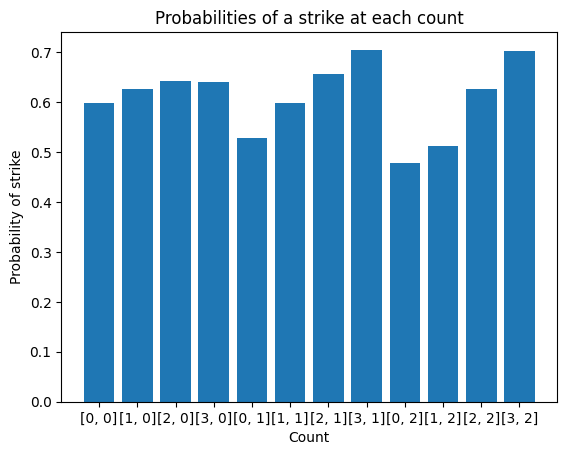

In [6]:
counts = []
unique_counts = []
for i in range(len(pitch_outcome_num)):
    count = [df.loc[i, 'balls'], df.loc[i, 'strikes']]
    counts.append(count)
    if count not in unique_counts:
        unique_counts.append(count)
#e
count_0_0 = []
count_1_0 = []
count_2_0 = []
count_3_0 = []
count_0_1 = []
count_1_1 = []
count_2_1 = []
count_3_1 = []
count_0_2 = []
count_1_2 = []
count_2_2 = []
count_3_2 = []
#seperating outcomes by count
for i in range(len(counts)):
    if counts[i] == [0,0]:
        if pitch_outcome_num[i] != 2:
            count_0_0.append(pitch_outcome_num[i])
    elif counts[i] == [1,0]:
        if pitch_outcome_num[i] != 2:
            count_1_0.append(pitch_outcome_num[i])
    elif counts[i] == [2,0]:
        if pitch_outcome_num[i] != 2:
            count_2_0.append(pitch_outcome_num[i])
    elif counts[i] == [3,0]:
        if pitch_outcome_num[i] != 2:
            count_3_0.append(pitch_outcome_num[i])
    elif counts[i] == [0,1]:
        if pitch_outcome_num[i] != 2:
            count_0_1.append(pitch_outcome_num[i])
    elif counts[i] == [1,1]:
        if pitch_outcome_num[i] != 2:
            count_1_1.append(pitch_outcome_num[i])
    elif counts[i] == [2,1]:
        if pitch_outcome_num[i] != 2:
            count_2_1.append(pitch_outcome_num[i])
    elif counts[i] == [3,1]:
        if pitch_outcome_num[i] != 2:
            count_3_1.append(pitch_outcome_num[i])
    elif counts[i] == [0,2]:
        if pitch_outcome_num[i] != 2:
            count_0_2.append(pitch_outcome_num[i])
    elif counts[i] == [1,2]:
        if pitch_outcome_num[i] != 2:
            count_1_2.append(pitch_outcome_num[i])
    elif counts[i] == [2,2]:
        if pitch_outcome_num[i] != 2:
            count_2_2.append(pitch_outcome_num[i])
    elif counts[i] == [3,2]:
        if pitch_outcome_num[i] != 2:
            count_3_2.append(pitch_outcome_num[i])
#determing probability
s_prob_list = []

s_prob = np.mean(count_0_0)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[0, 0] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_1_0)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[1, 0] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_2_0)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[2, 0] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_3_0)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[3, 0] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_0_1)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[0, 1] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_1_1)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[1, 1] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_2_1)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[2, 1] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_3_1)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[3, 1] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_0_2)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[0, 2] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_1_2)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[1, 2] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_2_2)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[2, 2] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(count_3_2)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("[3, 2] Count:", "probability of strike =", s_prob, "probability of ball =", b_prob)

names = ["[0, 0]", "[1, 0]", "[2, 0]", "[3, 0]", "[0, 1]", "[1, 1]","[2, 1]","[3, 1]", "[0, 2]", "[1, 2]", "[2, 2]", "[3, 2]",]

plt.bar(names, s_prob_list)
plt.title("Probabilities of a strike at each count")
plt.xlabel("Count")
plt.ylabel("Probability of strike")

0 Outs probability of strike = 0.6646341463414634 probability of ball = 0.33536585365853655
1 Outs probability of strike = 0.7288135593220338 probability of ball = 0.27118644067796616
2 Outs probability of strike = 0.7133333333333334 probability of ball = 0.2866666666666666


Text(0, 0.5, 'Probability of strike')

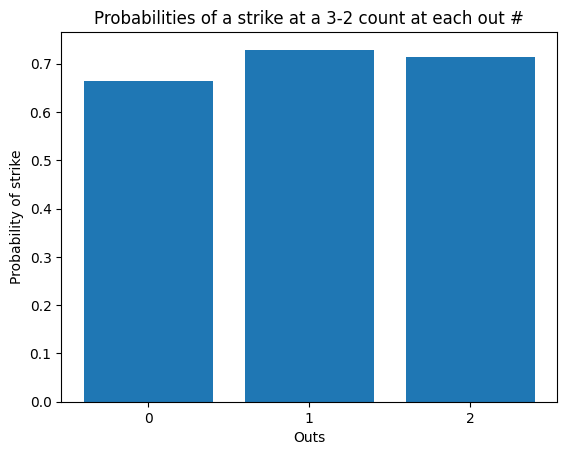

In [ ]:
outs_0 = []
outs_1 = []
outs_2 = []
for i in range(df.shape[0]):
    if counts[i] == [3, 2] and pitch_outcome_num[i] != 2:
        if df.loc[i, 'outs_when_up'] == 0:
            outs_0.append(pitch_outcome_num[i])
        elif df.loc[i, 'outs_when_up'] == 1:
            outs_1.append(pitch_outcome_num[i])
        elif df.loc[i, 'outs_when_up'] == 2:
            outs_2.append(pitch_outcome_num[i])

s_prob_list = []

s_prob = np.mean(outs_0)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("0 Outs", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(outs_1)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("1 Outs", "probability of strike =", s_prob, "probability of ball =", b_prob)

s_prob = np.mean(outs_2)
b_prob = 1- s_prob
s_prob_list.append(s_prob)
print("2 Outs", "probability of strike =", s_prob, "probability of ball =", b_prob)

outs = ['0', '1', '2']

plt.bar(outs, s_prob_list)
plt.title("Probabilities of a strike at a 3-2 count at each out #")
plt.xlabel("Outs")
plt.ylabel("Probability of strike")

# Pitcher Data
Looking for any obvious correlations between data points

In [4]:
pitchers = pd.read_csv('Data/Pitcher_Data.csv')
pitchers.head()

,"last_name, first_name",player_id,year,p_ball,p_called_strike,pitch_count,in_zone_percent,whiff_percent
0,"King, Michael",650633,2025,453,216,1219,48.3,25.8
1,"Adams, Travis",701519,2025,236,99,663,47.5,25.6
2,"Díaz, Edwin",621242,2025,371,167,1067,48.4,41.5
3,"Finnegan, Kyle",640448,2025,263,142,846,56.0,24.6
4,"Irvin, Jake",663623,2025,1011,524,2945,55.1,18.2


In [6]:
pitchers['called_strike%'] = pitchers['p_called_strike'] / pitchers['pitch_count'] * 100
pitchers['ball%'] = pitchers['p_ball'] / pitchers['pitch_count'] * 100

pitchers.head()

,"last_name, first_name",player_id,year,p_ball,p_called_strike,pitch_count,in_zone_percent,whiff_percent,called_strike%,ball%
0,"King, Michael",650633,2025,453,216,1219,48.3,25.8,17.719442,37.161608
1,"Adams, Travis",701519,2025,236,99,663,47.5,25.6,14.932127,35.595777
2,"Díaz, Edwin",621242,2025,371,167,1067,48.4,41.5,15.651359,34.770384
3,"Finnegan, Kyle",640448,2025,263,142,846,56.0,24.6,16.784870,31.087470
4,"Irvin, Jake",663623,2025,1011,524,2945,55.1,18.2,17.792869,34.329372


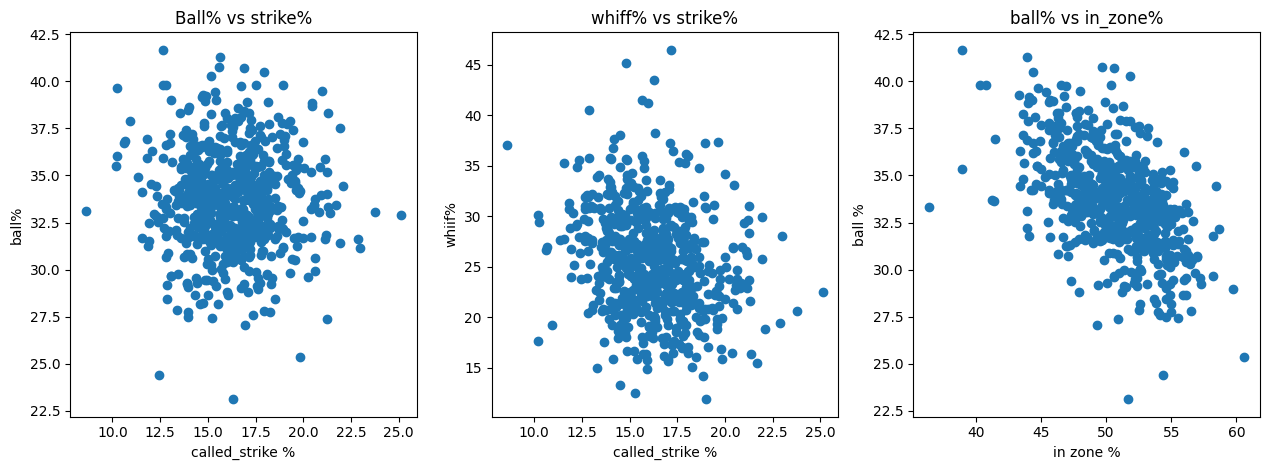

In [17]:
plt.subplot(1, 3, 1)
plt.scatter(pitchers['called_strike%'], pitchers['ball%'])
plt.title("Ball% vs strike%")
plt.xlabel('called_strike %')
plt.ylabel('ball%')

plt.subplot(1, 3, 2)
plt.scatter(pitchers['called_strike%'], pitchers['whiff_percent'])
plt.title("whiff% vs strike%")
plt.xlabel('called_strike %')
plt.ylabel('whiif%')

plt.subplot(1, 3, 3)
plt.scatter(pitchers['in_zone_percent'], pitchers['ball%'])
plt.title("ball% vs in_zone%")
plt.xlabel('in zone %')
plt.ylabel('ball %')

plt.tight_layout(rect = [0, 0, 2, 1])

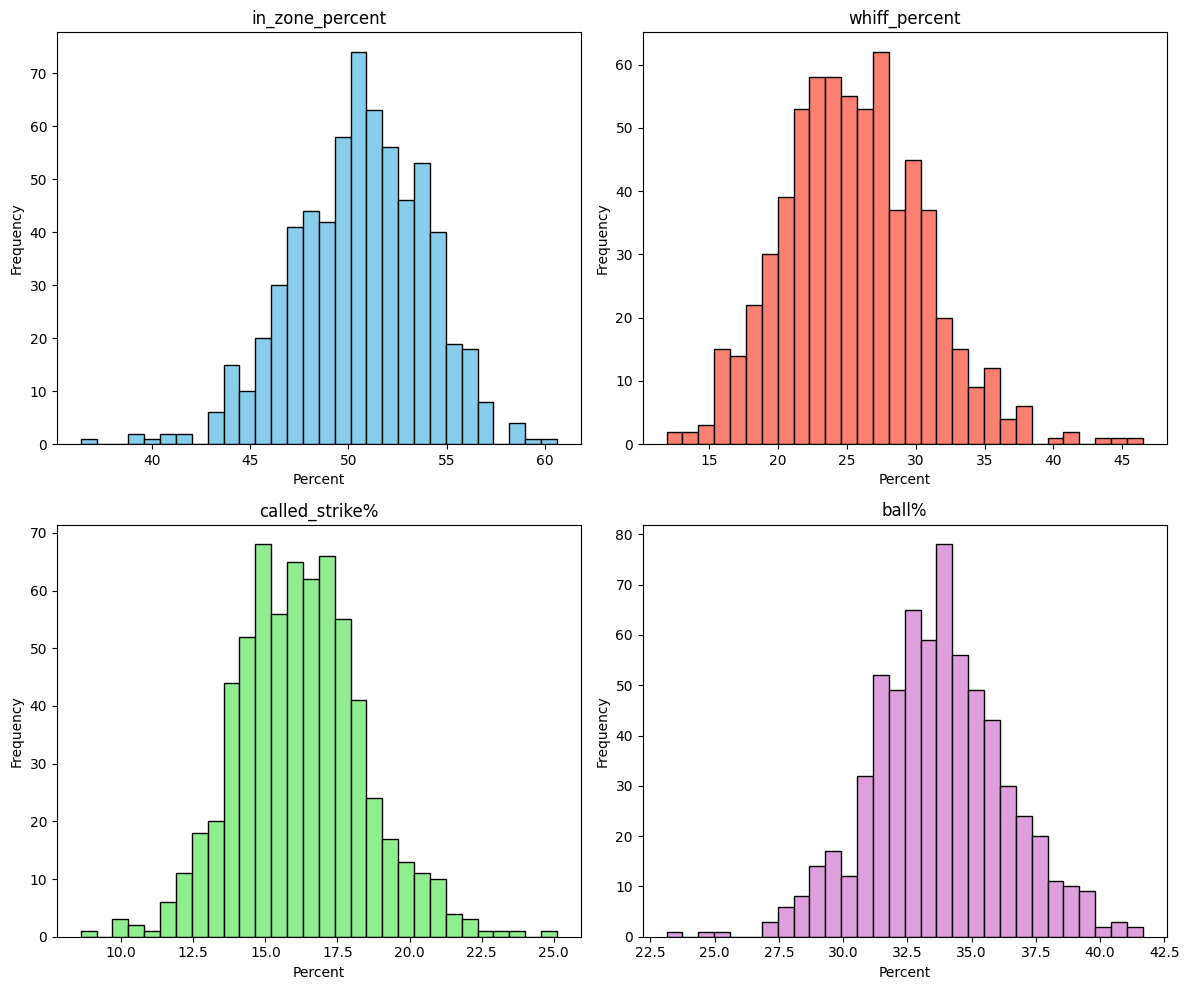

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.hist(pitchers['in_zone_percent'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('in_zone_percent')
plt.xlabel('Percent')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
plt.hist(pitchers['whiff_percent'].dropna(), bins=30, color='salmon', edgecolor='black')
plt.title('whiff_percent')
plt.xlabel('Percent')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
plt.hist(pitchers['called_strike%'].dropna(), bins=30, color='lightgreen', edgecolor='black')
plt.title('called_strike%')
plt.xlabel('Percent')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
plt.hist(pitchers['ball%'].dropna(), bins=30, color='plum', edgecolor='black')
plt.title('ball%')
plt.xlabel('Percent')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Batter stats
Looking for any heavy correlation and looking at distributions of the stats

In [22]:
batters = pd.read_csv('Data/batter_data.csv')

batters.head()

,"last_name, first_name",player_id,year,oz_swing_miss_percent,in_zone_percent
0,"Straw, Myles",664702,2025,29.9,55.9
1,"Naylor, Josh",647304,2025,38.0,47.4
2,"Robles, Victor",645302,2025,45.1,49.1
3,"Fortes, Nick",663743,2025,29.5,50.7
4,"Rivera, Emmanuel",656896,2025,48.9,47.3


Text(0, 0.5, 'Pitches outside zone swung at (%)')

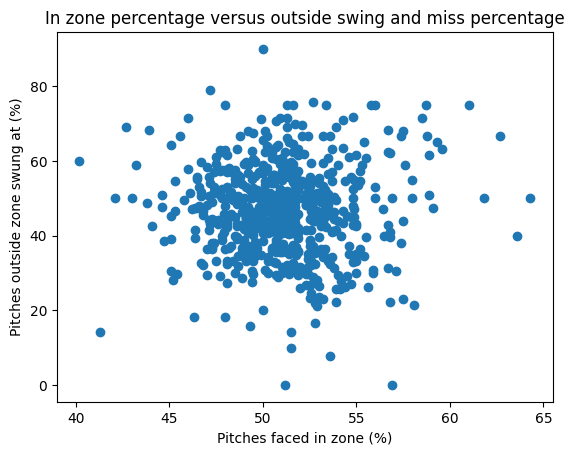

In [24]:

plt.scatter(batters['in_zone_percent'], batters['oz_swing_miss_percent'])
plt.title("In zone percentage versus outside swing and miss percentage")
plt.xlabel('Pitches faced in zone (%)')
plt.ylabel("Pitches outside zone swung at (%)")

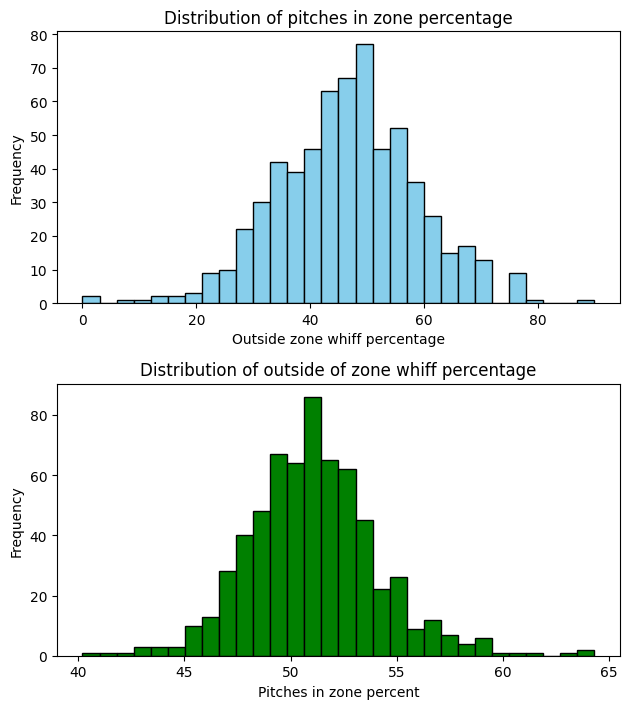

In [34]:
plt.subplot(2, 1, 1)
plt.hist(batters['oz_swing_miss_percent'], bins=30, color='skyblue', edgecolor='black');
plt.xlabel("Outside zone whiff percentage")
plt.ylabel("Frequency")
plt.title("Distribution of pitches in zone percentage")

plt.subplot(2, 1, 2)
plt.hist(batters['in_zone_percent'], bins=30, color='green', edgecolor='black');
plt.xlabel("Pitches in zone percent")
plt.ylabel("Frequency")
plt.title("Distribution of outside of zone whiff percentage")

plt.tight_layout(rect = [0, 0, 1, 1.5])

## Looking if handedness matchup influences balls and stikes

In [13]:
df["Handedness"] = np.where(df['stand'] == df['p_throws'], 0, 1)

same = df[df['Handedness'] == 0]
diff = df[df['Handedness'] == 1]

same_strike_prob = len(same[same['outcome'] == 1]) / len(same)
print(same_strike_prob)

diff_strike_prob = len(diff[diff['outcome'] == 1]) / len(diff)
print(diff_strike_prob)

0.466586754569973
0.46806790622473726
